In [ ]:
# 2.1 Simple neuron example in code

import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
def neuron_output(x1,x2,w1,w2,b):
    """"
    
    A simple neuron:
    z = w1*x1 + w2x2 +b
    Here we will not apply an activation yet, return return z.
    """
    
    z = w1 * x1 + w2 * x2 + b
    
    return z

#Example inputs (e.g hours studeied, extra classes attended)

x1 = 5 #feature 1
x2 = 2 # feature 2

# Example weights and bais

w1 = 0.8
w2 = 1.2

b = -1.0

z = neuron_output(x1,x2,w1,w2,b)
print('Linear combination (z):', z)

Linear combination (z): 5.4


> Exercise:
- pass the output through a step function
- Print a decision based on the output

Step function:
if the input is less that or equal to zero, output = 0
otherwise output = 1

In [ ]:
def activation(z):
    
    if z>=0:
        output = 1,
        print(output, 'yes, activates')
        
        
    else:
        output = 0,
        print(output, 'no, dont activate')
        
activation(z)
        

(1,) yes, activates


In [ ]:
def activation(z):
    if z > 0:
        return 1
    return 0


def outputs(y):
    if y == 0:
        print('Noops! We are not going anywhere')
    else:
        print('yaay, lets go')
        

outputs(activation(neuron_output(x1, x2, w1, w2, b)))

yaay, lets go


In [ ]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name = 'target')

print("X shape:",X.shape)
print("Class counts:\n", y.value_counts())
X.head()

X shape: (150, 4)
Class counts:
 target
0    50
1    50
2    50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (120, 4)
Test size: (30, 4)


In [ ]:
#Scale features (IMPORTANT for neural networks, we dont want to give wrong importance,we want nn to learn abt patterns of data)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# Optional: quick check mean/std after scaling

print("After scaling (train)")
print("Mean (approx):", np.round(X_train_scaled.mean(axis = 0),3))
print("Std (approx):", np.round(X_train_scaled.std(axis = 0),3))


After scaling (train)
Mean (approx): [-0. -0.  0.  0.]
Std (approx): [1. 1. 1. 1.]


In [ ]:
# Train an MLPClassifier (simple setup)

mlp = MLPClassifier(
    hidden_layer_sizes=(10,), # 1 hidden layer with 10 neurons
    activation="tanh",
    solver='adam',
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

#predict
y_pred = mlp.predict(X_test_scaled)

# Accuracy

acc = accuracy_score(y_test, y_pred)

print("===MLPClassifier on iris===")
print("Test Accuracy:",round(acc,4))

===MLPClassifier on iris===
Test Accuracy: 0.9667


c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


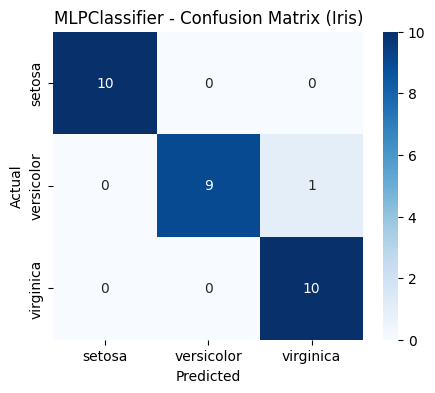

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
# confusion matrix + classification report 

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels = iris.target_names,
            yticklabels = iris.target_names)
plt.title("MLPClassifier - Confusion Matrix (Iris)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred, target_names=iris.target_names))

In [ ]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [ ]:
mlp_cancer = MLPClassifier(
    hidden_layer_sizes=((50,40,90)),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

mlp_cancer.fit(X_train_scaled,y_train)

y_pred = mlp_cancer.predict(X_test_scaled)

#accuracy:

acc = accuracy_score(y_test, y_pred)
print(acc)


0.9736842105263158
